# Stage 2: Scene-Specific Neural LOD Threshold Baker - Training Notebook

**Purpose**: Train an MLP regressor that maps camera pose (position + orientation) to optimal per-object LOD threshold vectors.

**Input data**: CSV files exported by the Unity `BakerOrchestrator` pipeline:
- `sample_records.csv` - performance measurements per (point, rotation, LOD level)
- `labels.csv` - oracle-optimal threshold vectors per viewpoint
- `grid_points.csv` - grid point coordinates
- `lod_objects.csv` - baseline LOD object metadata

**Output**: Trained ONNX model + scaler constants JSON for Unity deployment.

---


In [30]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

Paths are relative to `ml_pipeline/` root. Adjust `DATA_DIR` if your BakerExport folder is elsewhere.


In [ ]:
# paths relative to ml_pipeline root
BASE_DIR = Path('../..').resolve()  # ml_pipeline/
DATA_DIR = BASE_DIR / 'data' / 'Baker_1'
MODEL_DIR = BASE_DIR / 'models' / 'baker_1'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_FILE = DATA_DIR / 'sample_records.csv'
LABELS_FILE  = DATA_DIR / 'labels.csv'
GRID_FILE    = DATA_DIR / 'grid_points.csv'
OBJECTS_FILE = DATA_DIR / 'lod_objects.csv'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_2' / 'Train'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# hyperparameters
BATCH_SIZE    = 128       # reduced from 256 for better gradient signal
LEARNING_RATE = 5e-4      # reduced from 1e-3 for smoother convergence with AdamW
WEIGHT_DECAY  = 1e-4      # AdamW regularization
EPOCHS        = 300       # increased budget since AdamW converges slower
PATIENCE      = 30        # increased to give scheduler more room
HIDDEN_1      = 512       # doubled capacity
HIDDEN_2      = 256
HIDDEN_3      = 128
DROPOUT       = 0.2       # increased to counter larger model overfitting
HUBER_DELTA   = 0.15      # slightly relaxed from 0.1
FEATURE_COUNT = 13            # 9 pose + 4 complexity (set to 9 if complexity unavailable)
TEST_SPLIT    = 0.2
VAL_SPLIT     = 0.1
RANDOM_SEED   = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Data dir:  {DATA_DIR}')
print(f'Model dir: {MODEL_DIR}')
print(f'PLOTS_DIR dir: {PLOTS_DIR}')
print(f'GRID_FILE: {GRID_FILE}')
print(f'OBJECTS_FILE: {OBJECTS_FILE}')
for f in [SAMPLES_FILE, LABELS_FILE, GRID_FILE, OBJECTS_FILE]:
    status = 'FOUND' if f.exists() else 'MISSING'
    print(f'  {f.name}: {status}')
print()
print('Hyperparameters:')
print(f'  BATCH_SIZE={BATCH_SIZE}, LR={LEARNING_RATE}, WEIGHT_DECAY={WEIGHT_DECAY}')
print(f'  HIDDEN={HIDDEN_1}/{HIDDEN_2}/{HIDDEN_3}, DROPOUT={DROPOUT}')
print(f'  HUBER_DELTA={HUBER_DELTA}, PATIENCE={PATIENCE}, EPOCHS={EPOCHS}')


Data dir:  C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_1
Model dir: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1
PLOTS_DIR dir: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_2\Train
GRID_FILE: C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_1\grid_points.csv
OBJECTS_FILE: C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_1\lod_objects.csv
  sample_records.csv: FOUND
  labels.csv: FOUND
  grid_points.csv: FOUND
  lod_objects.csv: FOUND

Hyperparameters:
  BATCH_SIZE=128, LR=0.0005, WEIGHT_DECAY=0.0001
  HIDDEN=512/256/128, DROPOUT=0.2
  HUBER_DELTA=0.15, PATIENCE=30, EPOCHS=300


## 2. Load and inspect data


## 1.5. Preprocessing — Relabel with Budget

Recomputes `labels.csv` from `sample_records.csv` using a tighter frame time budget.
Required when the original 16.67ms budget is never exceeded and all labels collapse to one value.

Adjust `RELABEL_BUDGET_MS` to control aggressiveness:
- Lower = more LOD switching, more variance in labels
- `3.5` recommended for lightweight scenes
- Set `RUN_RELABELING = False` to skip if labels already have variance

In [32]:
# preprocessing: relabel dataset with tighter frame time budget
# fix 3: filter sky facing poses (rot_x extremes) before building labels
# outputs semicolon joined per object thresholds from lod_objects.csv
RUN_RELABELING    = True
RELABEL_BUDGET_MS = 3.5
SKY_PITCH_THRESH  = 45.0  # remove rows where abs(rot_x) >= this value

if RUN_RELABELING:
    from collections import defaultdict, Counter

    print(f"Relabeling with budget = {RELABEL_BUDGET_MS}ms ...")

    df_samples_raw = pd.read_csv(SAMPLES_FILE)
    df_objects_raw = pd.read_csv(OBJECTS_FILE)

    # fix 3: remove sky facing and floor facing poses
    before = len(df_samples_raw)
    df_samples_raw = df_samples_raw[df_samples_raw['rot_x'].abs() < SKY_PITCH_THRESH].copy()
    print(f"Removed {before - len(df_samples_raw)} sky/floor facing rows (|rot_x| >= {SKY_PITCH_THRESH})")

    lod_levels = sorted(df_samples_raw['lod_level'].unique())
    max_lod    = max(lod_levels)

    # build per object threshold lookup: object_index -> list of thresholds per lod
    # lod_objects.csv has semicolon joined thresholds per object
    obj_thresholds = []
    for _, row in df_objects_raw.iterrows():
        thresh_str = str(row['thresholds'])
        thresholds = [float(v) for v in thresh_str.split(';') if v.strip()]
        obj_thresholds.append(thresholds)

    # for a given optimal lod, compute mean threshold across all objects at that lod
    # this gives a single representative threshold vector
    def get_threshold_vector(optimal_lod):
        result = []
        for obj_thresh in obj_thresholds:
            if optimal_lod < len(obj_thresh):
                result.append(obj_thresh[optimal_lod])
            elif len(obj_thresh) > 0:
                result.append(obj_thresh[-1])
        if not result:
            return [1.0 - (optimal_lod / max_lod)]
        # return mean as single scalar for now since output dim is 1
        return [sum(result) / len(result)]

    groups = defaultdict(list)
    for _, row in df_samples_raw.iterrows():
        key = (row['point_id'], row['rot_x'], row['rot_y'], row['rot_z'])
        groups[key].append(row)

    label_rows     = []
    fallback_count = 0
    lod_dist       = Counter()

    for key, group in groups.items():
        point_id, rot_x, rot_y, rot_z = key
        group_sorted = sorted(group, key=lambda r: int(r['lod_level']))

        optimal_lod = None
        for rec in group_sorted:
            cost = max(float(rec['mean_gpu_ms']), float(rec['mean_cpu_ms']))
            if cost <= RELABEL_BUDGET_MS:
                optimal_lod = int(rec['lod_level'])
                break

        if optimal_lod is None:
            best = min(group_sorted, key=lambda r: max(float(r['mean_gpu_ms']), float(r['mean_cpu_ms'])))
            optimal_lod = int(best['lod_level'])
            fallback_count += 1

        lod_dist[optimal_lod] += 1
        thresh_vec = get_threshold_vector(optimal_lod)
        label_rows.append({
            'point_id':           point_id,
            'rot_x':              rot_x,
            'rot_y':              rot_y,
            'rot_z':              rot_z,
            'optimal_thresholds': ';'.join(f'{v:.7f}' for v in thresh_vec),
            'optimal_lod':        optimal_lod
        })

    df_new_labels = pd.DataFrame(label_rows)
    df_new_labels.to_csv(LABELS_FILE, index=False)

    print(f"Labels written: {len(label_rows)}")
    print(f"Fallbacks: {fallback_count} ({100*fallback_count/len(label_rows):.1f}%)")
    print("LOD distribution:")
    for lod in sorted(lod_dist):
        count = lod_dist[lod]
        pct   = 100 * count / len(label_rows)
        print(f"  LOD {lod}: {count} ({pct:.1f}%)")
else:
    print("Relabeling skipped.")


Relabeling with budget = 3.5ms ...
Removed 48000 sky/floor facing rows (|rot_x| >= 45.0)
Labels written: 6000
Fallbacks: 2356 (39.3%)
LOD distribution:
  LOD 0: 2248 (37.5%)
  LOD 1: 231 (3.9%)
  LOD 2: 132 (2.2%)
  LOD 3: 3389 (56.5%)


In [33]:
# load CSVs
df_samples = pd.read_csv(SAMPLES_FILE)
df_labels = pd.read_csv(LABELS_FILE)
df_grid = pd.read_csv(GRID_FILE)
df_objects = pd.read_csv(OBJECTS_FILE)

print(f"Sample records: {len(df_samples):,} rows")
print(f"Labels: {len(df_labels):,} rows")
print(f"Grid points: {len(df_grid):,}")
print(f"LOD objects: {len(df_objects):,}")

print("\n--- Sample records columns ---")
print(df_samples.columns.tolist())
print(df_samples.head())

print("\n--- Labels columns ---")
print(df_labels.columns.tolist())
print(df_labels.head())


Sample records: 72,000 rows
Labels: 6,000 rows
Grid points: 500
LOD objects: 14,752

--- Sample records columns ---
['point_id', 'rot_x', 'rot_y', 'rot_z', 'lod_level', 'mean_gpu_ms', 'mean_cpu_ms', 'mean_fps']
   point_id  rot_x  rot_y  rot_z  lod_level  mean_gpu_ms  mean_cpu_ms  \
0         0    -60      0    -30          0     4.745387     1.906500   
1         0    -60      0    -30          1     1.843836     2.285348   
2         0    -60      0    -30          2     1.835486     1.833290   
3         0    -60      0    -30          3     1.869005     1.962234   
4         0    -60      0      0          0     1.823320     2.496221   

   mean_fps  
0  210.7310  
1  437.5701  
2  544.8149  
3  509.6233  
4  400.6056  

--- Labels columns ---
['point_id', 'rot_x', 'rot_y', 'rot_z', 'optimal_thresholds', 'optimal_lod']
   point_id  rot_x  rot_y  rot_z  optimal_thresholds  optimal_lod
0       0.0    0.0    0.0  -30.0            0.045003            3
1       0.0    0.0    0.0    0.0 

## 3. Parse and prepare features/targets

The `optimal_thresholds` column contains semicolon-separated float vectors. We parse these into fixed-width arrays.


In [34]:
# parse optimal_thresholds from semicolon-separated string to list of floats
df_labels["thresh_parsed"] = df_labels["optimal_thresholds"].apply(
    lambda s: [float(v) for v in str(s).split(";")] if pd.notna(s) else []
)

# determine output dimension (number of thresholds per prediction)
thresh_lengths = df_labels["thresh_parsed"].apply(len)
OUTPUT_DIM = int(thresh_lengths.mode().iloc[0])
print(f"Output dimension (thresholds per sample): {OUTPUT_DIM}")

# filter rows with correct length
mask = thresh_lengths == OUTPUT_DIM
df_labels_clean = df_labels[mask].copy()
print(f"Labels after filtering: {len(df_labels_clean):,} / {len(df_labels):,}")

# build target matrix
targets = np.array(df_labels_clean["thresh_parsed"].tolist(), dtype=np.float32)
print(f"Target shape: {targets.shape}")
print(f"Target range: [{targets.min():.4f}, {targets.max():.4f}]")


Output dimension (thresholds per sample): 1
Labels after filtering: 6,000 / 6,000
Target shape: (6000, 1)
Target range: [0.0450, 0.3041]


In [35]:
# features: position (x,y,z) + rotation sin/cos encoding + scene complexity
# complexity features joined from sample_records at LOD0 (baseline complexity at that pose)

positions = df_labels_clean[["rot_x", "rot_y", "rot_z"]].values.astype(np.float32)

# grid point coordinates
grid_lookup = df_grid.set_index("point_id")[["x", "y", "z"]]
point_coords = df_labels_clean["point_id"].map(
    lambda pid: grid_lookup.loc[pid].values if pid in grid_lookup.index else np.zeros(3)
)
point_coords = np.array(point_coords.tolist(), dtype=np.float32)

# rotation sin/cos encoding
rot_rad = np.deg2rad(positions)
sin_rot = np.sin(rot_rad)
cos_rot = np.cos(rot_rad)

# join complexity features from sample_records at LOD0 for each (point, rot_x, rot_y, rot_z)
complexity_cols = ['triangle_count', 'visible_renderer_count', 'screen_coverage', 'draw_call_count']
has_complexity = all(c in df_samples.columns for c in complexity_cols)

if has_complexity:
    lod0_samples = df_samples[df_samples['lod_level'] == 0][
        ['point_id', 'rot_x', 'rot_y', 'rot_z'] + complexity_cols
    ].copy()

    df_labels_clean = df_labels_clean.merge(
        lod0_samples,
        on=['point_id', 'rot_x', 'rot_y', 'rot_z'],
        how='left'
    )

    for col in complexity_cols:
        df_labels_clean[col] = df_labels_clean[col].fillna(0.0)

    complexity_features = df_labels_clean[complexity_cols].values.astype(np.float32)

    features = np.hstack([
        point_coords,
        sin_rot[:, 0:1],
        cos_rot[:, 0:1],
        sin_rot[:, 1:2],
        cos_rot[:, 1:2],
        sin_rot[:, 2:3],
        cos_rot[:, 2:3],
        complexity_features
    ])

    feature_names = [
        "pos_x", "pos_y", "pos_z",
        "sin_pitch", "cos_pitch",
        "sin_yaw", "cos_yaw",
        "sin_roll", "cos_roll",
        "triangle_count", "visible_renderer_count", "screen_coverage", "draw_call_count"
    ]
    print("Complexity features: INCLUDED")
else:
    features = np.hstack([
        point_coords,
        sin_rot[:, 0:1],
        cos_rot[:, 0:1],
        sin_rot[:, 1:2],
        cos_rot[:, 1:2],
        sin_rot[:, 2:3],
        cos_rot[:, 2:3],
    ])
    feature_names = [
        "pos_x", "pos_y", "pos_z",
        "sin_pitch", "cos_pitch",
        "sin_yaw", "cos_yaw",
        "sin_roll", "cos_roll"
    ]
    print("Complexity features: MISSING from sample_records, using pose only")

INPUT_DIM = features.shape[1]
print(f"Feature matrix shape: {features.shape}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Feature names: {feature_names}")

# update FEATURE_COUNT to match actual input dim
FEATURE_COUNT = INPUT_DIM


Complexity features: MISSING from sample_records, using pose only
Feature matrix shape: (6000, 9)
Input dimension: 9
Feature names: ['pos_x', 'pos_y', 'pos_z', 'sin_pitch', 'cos_pitch', 'sin_yaw', 'cos_yaw', 'sin_roll', 'cos_roll']


## 4. Normalize features and split dataset


In [36]:
# normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features).astype(np.float32)

# save scaler constants for Unity deployment
scaler_dict = {
    "feature_names": feature_names,
    "mean":  scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "input_dim":  int(INPUT_DIM),
    "output_dim": int(OUTPUT_DIM)
}
scaler_path = MODEL_DIR / "baker_scaler_constants.json"
with open(scaler_path, "w") as f:
    json.dump(scaler_dict, f, indent=2)
print(f"Scaler constants saved to: {scaler_path}")

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, targets,
    test_size=TEST_SPLIT,
    random_state=RANDOM_SEED
)

# train/val split from training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SPLIT,
    random_state=RANDOM_SEED
)

print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")


Scaler constants saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\baker_scaler_constants.json
Train: 4,320
Val:   480
Test:  1,200


## 5. PyTorch dataset and model definition


In [37]:
class BakerDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = BakerDataset(X_train, y_train)
val_ds   = BakerDataset(X_val,   y_val)
test_ds  = BakerDataset(X_test,  y_test)

# fix 2: weighted random sampler to address class imbalance
# discretize targets to lod levels for weight computation
# target = 1 - (lod / max_lod) so lod = round((1 - target) * max_lod)
if 'optimal_lod' in df_labels_clean.columns:
    # use the lod column directly if available from relabeling
    train_lod_labels = df_labels_clean['optimal_lod'].values
    # align to train indices
    all_indices = np.arange(len(df_labels_clean))
    X_all = features_scaled
    # recompute train split indices for weighting
    from sklearn.model_selection import train_test_split as tts
    idx_trainval, _ = tts(all_indices, test_size=TEST_SPLIT, random_state=RANDOM_SEED)
    idx_train, _    = tts(idx_trainval, test_size=VAL_SPLIT, random_state=RANDOM_SEED)
    train_lods = train_lod_labels[idx_train]
    class_counts = np.bincount(train_lods)
    class_counts = np.where(class_counts == 0, 1, class_counts)
    sample_weights = 1.0 / class_counts[train_lods]
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(train_ds),
        replacement=True
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
    print("WeightedRandomSampler: ENABLED")
    for lod, cnt in enumerate(class_counts):
        if cnt > 0:
            print(f"  LOD {lod}: {cnt} samples, weight={1.0/cnt:.6f}")
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    print("WeightedRandomSampler: SKIPPED (optimal_lod column not found, using shuffle)")

val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


WeightedRandomSampler: ENABLED
  LOD 0: 1616 samples, weight=0.000619
  LOD 1: 164 samples, weight=0.006098
  LOD 2: 97 samples, weight=0.010309
  LOD 3: 2443 samples, weight=0.000409
Train batches: 34
Val batches:   4
Test batches:  10


In [38]:
class BakerMLP(nn.Module):
    # MLP regressor: pose features -> optimal threshold vector
    def __init__(self, input_dim, output_dim, h1, h2, h3, dropout):
        super(BakerMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.GELU(),
            nn.Linear(h3, output_dim),
            nn.Sigmoid()  # thresholds are in [0, 1]
        )

    def forward(self, x):
        return self.net(x)

model = BakerMLP(INPUT_DIM, OUTPUT_DIM, HIDDEN_1, HIDDEN_2, HIDDEN_3, DROPOUT).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


BakerMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=128, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
Total parameters: 169,473


## 5.5. Hyperparameter Tuning (Optuna)

Searches over learning rate, weight decay, batch size, hidden dims, dropout, and Huber delta.
Runs `N_TRIALS` trials, each training for `TUNE_EPOCHS` epochs max with early stopping.
Best params are written back into the config variables used by the main training cell.

Set `RUN_TUNING = False` to skip and use manual config values.

In [39]:
RUN_TUNING  = True
N_TRIALS    = 30     # number of Optuna trials
TUNE_EPOCHS = 40     # epochs per trial (short run for speed)
TUNE_PATIENCE = 10   # early stopping patience per trial

if RUN_TUNING:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        # search space
        lr           = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        batch_size   = trial.suggest_categorical('batch_size', [64, 128, 256])
        h1           = trial.suggest_categorical('h1', [128, 256, 512])
        h2           = trial.suggest_categorical('h2', [64,  128, 256])
        h3           = trial.suggest_categorical('h3', [32,  64,  128])
        dropout      = trial.suggest_float('dropout',      0.05, 0.4)
        huber_delta  = trial.suggest_float('huber_delta',  0.05, 0.3)

        # guard against inverted hidden dims
        if h2 > h1 or h3 > h2:
            raise optuna.exceptions.TrialPruned()

        trial_model = BakerMLP(INPUT_DIM, OUTPUT_DIM, h1, h2, h3, dropout).to(device)
        trial_crit  = nn.HuberLoss(delta=huber_delta)
        trial_opt   = optim.AdamW(trial_model.parameters(), lr=lr, weight_decay=weight_decay)
        trial_sched = optim.lr_scheduler.CosineAnnealingLR(trial_opt, T_max=TUNE_EPOCHS, eta_min=1e-6)

        trial_loader = torch.utils.data.DataLoader(
            train_ds, batch_size=batch_size, shuffle=True
        )

        best_val  = float('inf')
        pat       = 0

        for epoch in range(TUNE_EPOCHS):
            trial_model.train()
            for X_b, y_b in trial_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                trial_opt.zero_grad()
                trial_crit(trial_model(X_b), y_b).backward()
                trial_opt.step()
            trial_sched.step()

            trial_model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X_b, y_b in val_loader:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    val_loss += trial_crit(trial_model(X_b), y_b).item()
            val_loss /= len(val_loader)

            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            if val_loss < best_val:
                best_val = val_loss
                pat = 0
            else:
                pat += 1
            if pat >= TUNE_PATIENCE:
                break

        return best_val

    study = optuna.create_study(
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_params
    print('\n=== Best Hyperparameters ===')
    for k, v in best.items():
        print(f'  {k}: {v}')
    print(f'  best_val_loss: {study.best_value:.6f}')

    # write best params back into config variables
    LEARNING_RATE = best['lr']
    WEIGHT_DECAY  = best['weight_decay']
    BATCH_SIZE    = best['batch_size']
    HIDDEN_1      = best['h1']
    HIDDEN_2      = best['h2']
    HIDDEN_3      = best['h3']
    DROPOUT       = best['dropout']
    HUBER_DELTA   = best['huber_delta']

    # rebuild dataloaders with tuned batch size
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # rebuild model with tuned architecture
    model = BakerMLP(INPUT_DIM, OUTPUT_DIM, HIDDEN_1, HIDDEN_2, HIDDEN_3, DROPOUT).to(device)

    # save tuning results to JSON
    import json as _json
    tune_log = {'best_params': best, 'best_val_loss': study.best_value, 'n_trials': N_TRIALS}
    with open(str(MODEL_DIR / 'tuning_results.json'), 'w') as _f:
        _json.dump(tune_log, _f, indent=2)
    print(f'Tuning results saved to: {MODEL_DIR / "tuning_results.json"}')
    print('Config variables updated. Proceeding to full training with best params.')
else:
    print('Tuning skipped. Using manual config values.')


Best trial: 16. Best value: 0.000767481: 100%|██████████| 30/30 [03:28<00:00,  6.94s/it]


=== Best Hyperparameters ===
  lr: 0.0016313159836433904
  weight_decay: 5.5357207588733636e-05
  batch_size: 64
  h1: 256
  h2: 256
  h3: 128
  dropout: 0.05526732985536534
  huber_delta: 0.05366469226590671
  best_val_loss: 0.000767
Tuning results saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\tuning_results.json
Config variables updated. Proceeding to full training with best params.


## 6. Training loop with early stopping


In [40]:
criterion  = nn.HuberLoss(delta=HUBER_DELTA)
optimizer  = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2, eta_min=1e-6)

train_losses   = []
val_losses     = []
best_val_loss  = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            epoch_val_loss += criterion(pred, y_batch).item()
    epoch_val_loss /= len(val_loader)

    scheduler.step()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss    = epoch_val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 1 == 0 and (patience_counter == 0 or (epoch + 1) % 10 == 0):
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train: {epoch_train_loss:.6f} | '
              f'Val: {epoch_val_loss:.6f} | Best: {best_val_loss:.6f} | '
              f'Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(best_model_state)
print(f'Best validation loss: {best_val_loss:.6f}')


Epoch   1/300 | Train: 0.004503 | Val: 0.002024 | Best: 0.002024 | Patience: 0/30
Epoch   2/300 | Train: 0.001844 | Val: 0.001509 | Best: 0.001509 | Patience: 0/30
Epoch   3/300 | Train: 0.001495 | Val: 0.001295 | Best: 0.001295 | Patience: 0/30
Epoch   4/300 | Train: 0.001316 | Val: 0.001291 | Best: 0.001291 | Patience: 0/30
Epoch   5/300 | Train: 0.001255 | Val: 0.001050 | Best: 0.001050 | Patience: 0/30
Epoch   6/300 | Train: 0.001170 | Val: 0.001026 | Best: 0.001026 | Patience: 0/30
Epoch   8/300 | Train: 0.001029 | Val: 0.000903 | Best: 0.000903 | Patience: 0/30
Epoch  10/300 | Train: 0.000968 | Val: 0.000880 | Best: 0.000880 | Patience: 0/30
Epoch  12/300 | Train: 0.000934 | Val: 0.000816 | Best: 0.000816 | Patience: 0/30
Epoch  18/300 | Train: 0.000813 | Val: 0.000813 | Best: 0.000813 | Patience: 0/30
Epoch  20/300 | Train: 0.000802 | Val: 0.000910 | Best: 0.000813 | Patience: 2/30
Epoch  22/300 | Train: 0.000763 | Val: 0.000783 | Best: 0.000783 | Patience: 0/30
Epoch  30/300 | 

## 7. Training diagnostics


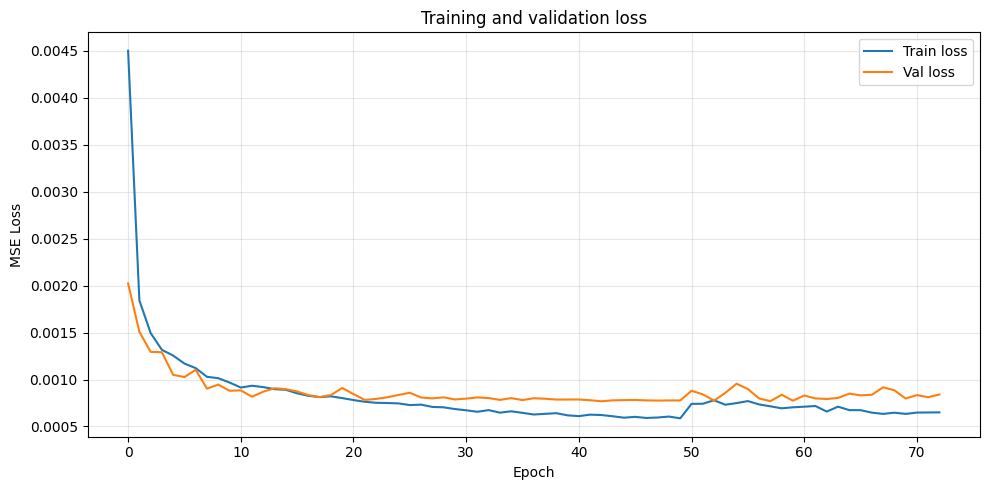

Loss curve saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\baker_loss_curve.png


In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label="Train loss", linewidth=1.5)
ax.plot(val_losses, label="Val loss", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'baker_loss_curve.png', dpi=150)
plt.show()
print(f"Loss curve saved to: {MODEL_DIR / 'baker_loss_curve.png'}")


## 8. Test set evaluation


In [42]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())

preds = np.concatenate(all_preds, axis=0)
truths = np.concatenate(all_targets, axis=0)

# per-output metrics
print("Per-threshold metrics:")
print(f"{'Threshold':<12} {'MAE':>8} {'RMSE':>8}")
print("-" * 30)
for i in range(OUTPUT_DIM):
    mae = mean_absolute_error(truths[:, i], preds[:, i])
    rmse = np.sqrt(mean_squared_error(truths[:, i], preds[:, i]))
    print(f"  thresh_{i:<4} {mae:>8.4f} {rmse:>8.4f}")

# aggregate metrics
overall_mae = mean_absolute_error(truths.flatten(), preds.flatten())
overall_rmse = np.sqrt(mean_squared_error(truths.flatten(), preds.flatten()))
print(f"\nOverall MAE:  {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")


Per-threshold metrics:
Threshold         MAE     RMSE
------------------------------
  thresh_0      0.0231   0.0548

Overall MAE:  0.0231
Overall RMSE: 0.0548


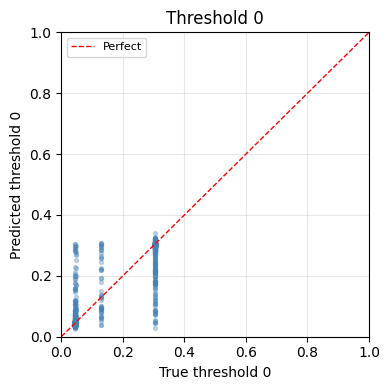


=== Scatter Diagnostic ===
  pred_mean: 0.1445
  pred_std: 0.118
  pred_min: 0.0267
  pred_max: 0.3416
  pred_range: 0.3149
  true_unique: [0.045, 0.0467, 0.1293, 0.3041]
  verdict: OK: predictions span a reasonable range (mean=0.144, std=0.1180).
Saved to: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\scatter_diagnostic.json


In [43]:
fig, axes = plt.subplots(1, min(OUTPUT_DIM, 4), figsize=(4 * min(OUTPUT_DIM, 4), 4))
if OUTPUT_DIM == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    if i >= OUTPUT_DIM:
        break
    ax.scatter(truths[:, i], preds[:, i], alpha=0.3, s=8, c="steelblue")
    ax.plot([0, 1], [0, 1], "r--", linewidth=1, label="Perfect")
    ax.set_xlabel(f"True threshold {i}")
    ax.set_ylabel(f"Predicted threshold {i}")
    ax.set_title(f"Threshold {i}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PLOTS_DIR  / "baker_pred_vs_true.png"), dpi=150)
plt.show()

# scatter plot diagnostic log
pred_mean  = float(preds.mean())
pred_std   = float(preds.std())
true_vals  = sorted(set(truths[:, 0].tolist()))
pred_range = float(preds.max() - preds.min())

if pred_std < 0.05:
    scatter_verdict = "FAIL: model predicts near-constant output (mean={:.3f}, std={:.4f}). Likely cause: class imbalance or loss collapse.".format(pred_mean, pred_std)
elif pred_range < 0.2:
    scatter_verdict = "WARN: prediction range is narrow ({:.3f}). Model may be underusing spatial signal.".format(pred_range)
else:
    scatter_verdict = "OK: predictions span a reasonable range (mean={:.3f}, std={:.4f}).".format(pred_mean, pred_std)

scatter_log = {
    "pred_mean":      round(pred_mean, 4),
    "pred_std":       round(pred_std, 4),
    "pred_min":       round(float(preds.min()), 4),
    "pred_max":       round(float(preds.max()), 4),
    "pred_range":     round(pred_range, 4),
    "true_unique":    [round(v, 4) for v in true_vals],
    "verdict":        scatter_verdict
}

import json
log_path = MODEL_DIR / "scatter_diagnostic.json"
with open(str(log_path), "w") as f:
    json.dump(scatter_log, f, indent=2)

print("\n=== Scatter Diagnostic ===")
for k, v in scatter_log.items():
    print(f"  {k}: {v}")
print(f"Saved to: {log_path}")

## 9. Feature importance (permutation)


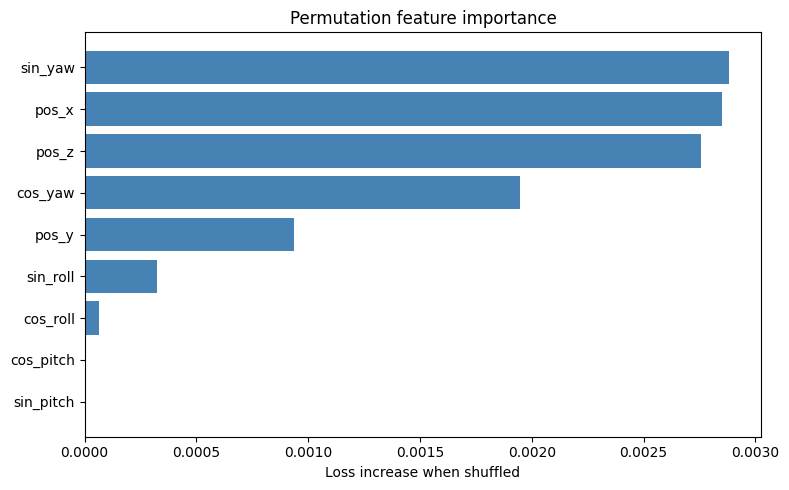


=== Feature Importance Diagnostic ===
  Base loss:    0.000809
  Top feature:  sin_yaw (0.002882)
  Near-zero:    ['pos_y', 'sin_pitch', 'cos_pitch', 'sin_roll', 'cos_roll']
  Negative:     []
  Verdict:      FAIL: all features near-zero importance. Model is not using input signal — likely predicting constant.
  Saved to:     C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\feature_importance_diagnostic.json


In [44]:
# permutation importance on test set
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    base_loss = criterion(model(X_test_t), y_test_t).item()

importances = []
for i in range(INPUT_DIM):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(device)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importances.append(perm_loss - base_loss)

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = np.argsort(importances)[::-1]
ax.barh(
    [feature_names[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color="steelblue"
)
ax.set_xlabel("Loss increase when shuffled")
ax.set_title("Permutation feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(PLOTS_DIR  / "baker_feature_importance.png"), dpi=150)
plt.show()

# feature importance diagnostic log
importance_ranked = [
    {"feature": feature_names[i], "importance": round(importances[i], 6)}
    for i in sorted_idx
]

top_feature    = feature_names[sorted_idx[0]]
top_importance = importances[sorted_idx[0]]
near_zero      = [feature_names[i] for i in range(INPUT_DIM) if importances[i] < 0.001]
negative       = [feature_names[i] for i in range(INPUT_DIM) if importances[i] < 0]

if top_importance < 0.01:
    importance_verdict = "FAIL: all features near-zero importance. Model is not using input signal — likely predicting constant."
elif len(near_zero) >= INPUT_DIM - 2:
    importance_verdict = "WARN: only 1-2 features matter. Model may be ignoring most of the pose signal."
elif len(negative) > 3:
    importance_verdict = "WARN: many negative importances detected. Model may be overfitting or underfitting."
else:
    importance_verdict = "OK: multiple features contribute meaningfully. Spatial signal is being used."

importance_log = {
    "base_loss":        round(base_loss, 6),
    "top_feature":      top_feature,
    "top_importance":   round(top_importance, 6),
    "near_zero_features": near_zero,
    "negative_features":  negative,
    "ranked":           importance_ranked,
    "verdict":          importance_verdict
}

import json
log_path = MODEL_DIR / "feature_importance_diagnostic.json"
with open(str(log_path), "w") as f:
    json.dump(importance_log, f, indent=2)

print("\n=== Feature Importance Diagnostic ===")
print(f"  Base loss:    {base_loss:.6f}")
print(f"  Top feature:  {top_feature} ({top_importance:.6f})")
print(f"  Near-zero:    {near_zero}")
print(f"  Negative:     {negative}")
print(f"  Verdict:      {importance_verdict}")
print(f"  Saved to:     {log_path}")

## 10. Export model


In [45]:
# save PyTorch checkpoint
pt_path = MODEL_DIR / "baker_best_model.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": INPUT_DIM,
    "output_dim": OUTPUT_DIM,
    "hidden_1": HIDDEN_1,
    "hidden_2": HIDDEN_2,
    "hidden_3": HIDDEN_3,
    "dropout": DROPOUT,
    "best_val_loss": best_val_loss,
    "feature_names": feature_names,
}, pt_path)
print(f"PyTorch model saved: {pt_path}")


PyTorch model saved: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1\baker_best_model.pt


In [46]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)
onnx_path = MODEL_DIR / "lod_baker.onnx"

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=15,
    input_names=["features"],
    output_names=["thresholds"],
    dynamic_axes={
        "features":   {0: "batch_size"},
        "thresholds": {0: "batch_size"}
    }
)

W0327 00:33:42.130000 10104 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `BakerMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BakerMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).
Failed to convert the model to the target version 15 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\Gica\neural-lod\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Gica\neural-lod\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\Gica\neural-lod\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Gica\neural-lod\.venv\Lib\site

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"features"<FLOAT,[batch_size,9]>
            ),
            outputs=(
                %"thresholds"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"net.0.bias"<FLOAT,[256]>{TorchTensor(...)},
                %"net.3.bias"<FLOAT,[256]>{TorchTensor(...)},
                %"net.6.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"net.8.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"net.8.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([-0.0099], requires_grad=True), name='net.8.bias')},
                %"net.0.weight"<FLOAT,[256,9]>{TorchTensor(...)},
                %"net.3.weight"<FLOAT,[256,256

In [47]:
# verify ONNX model loads correctly
try:
    import onnx
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)
    print("ONNX model verification: PASSED")
    print(f"  Inputs:  {[i.name for i in onnx_model.graph.input]}")
    print(f"  Outputs: {[o.name for o in onnx_model.graph.output]}")
except ImportError:
    print("onnx package not installed, skipping verification")
    print("Install with: pip install onnx")
except Exception as e:
    print(f"ONNX verification FAILED: {e}")


ONNX model verification: PASSED
  Inputs:  ['features']
  Outputs: ['thresholds']


## 11. Deployment to Unity

**Files to copy to Unity project:**

| File | Destination |
|------|------------|
| `lod_baker.onnx` | `Assets/StreamingAssets/` |
| `baker_scaler_constants.json` | `Assets/StreamingAssets/` |

**Unity setup:**
1. Update `LODThresholdPredictor.cs` field `modelFileName` to `"lod_baker.onnx"`
2. The predictor builds a 9-feature vector: `[pos_x, pos_y, pos_z, sin_pitch, cos_pitch, sin_yaw, cos_yaw, sin_roll, cos_roll]`
3. Features must be normalized using the means/stds from `baker_scaler_constants.json`
4. Model output is a vector of `OUTPUT_DIM` floats in [0, 1], applied directly as `screenRelativeTransitionHeight` values

**Metrics summary is printed above in section 8.**


In [48]:
onnx_size = os.path.getsize(onnx_path)

print("=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"Input features:   {INPUT_DIM}")
print(f"Output thresholds: {OUTPUT_DIM}")
print(f"Best val loss:    {best_val_loss:.6f}")
print(f"Test MAE:         {overall_mae:.4f}")
print(f"Test RMSE:        {overall_rmse:.4f}")
print(f"Model params:     {total_params:,}")
print(f"ONNX size:        {onnx_size / 1024:.1f} KB")
print(f"\nFiles saved in: {MODEL_DIR}")
for f in MODEL_DIR.iterdir():
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")


TRAINING COMPLETE
Input features:   9
Output thresholds: 1
Best val loss:    0.000768
Test MAE:         0.0231
Test RMSE:        0.0548
Model params:     169,473
ONNX size:        23.8 KB

Files saved in: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_1
  baker_best_model.pt (400.1 KB)
  baker_feature_importance.png (31.7 KB)
  baker_loss_curve.png (65.5 KB)
  baker_pred_vs_true.png (35.8 KB)
  baker_scaler_constants.json (0.6 KB)
  feature_importance_diagnostic.json (1.0 KB)
  lod_baker.onnx (23.8 KB)
  lod_baker.onnx.data (396.0 KB)
  scatter_diagnostic.json (0.3 KB)
  tuning_results.json (0.3 KB)
